In [1]:
! git clone https://github.com/ultralytics/yolov5

Cloning into 'yolov5'...
remote: Enumerating objects: 17847, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 17847 (delta 25), reused 6 (delta 6), pack-reused 17806 (from 3)
Receiving objects: 100% (17847/17847), 16.97 MiB | 13.06 MiB/s, done.
Resolving deltas: 100% (12159/12159), done.


In [2]:
%cd yolov5/
%pip install -r requirements.txt

/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 6.5 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [3]:
#! python train.py --img 1861 --data dataset.yaml --epochs 30 --weights 'yolov5s.pt'

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten,BatchNormalization
from tensorflow.keras.layers import Dense, MaxPooling2D
from tensorflow.keras.layers import Input,Activation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import applications
from keras.callbacks import ModelCheckpoint

In [7]:
train = list(os.walk(r"/content/drive/MyDrive/facemask/Custome data/train/Images"))

In [8]:
label_names = train[0][1]
dict_labels = dict(zip(label_names, list(range(len(label_names)))))
print(dict_labels)

{'cloth': 0, 'n95': 1, 'nfm': 2, 'srg': 3, 'n95v': 4}


In [9]:
def dataset(path):
    images = []
    labels = []
    for folder in os.listdir(path):
        value_of_label = dict_labels[folder]

        for file in (os.listdir(os.path.join(path, folder))):
            path_of_file = os.path.join(os.path.join(path, folder), file)

            image = cv2.imread(path_of_file)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (224, 224))
            images.append(image)
            labels.append(value_of_label)

    images = np.array(images, dtype = 'float32')/255.0
    labels = np.array(labels)

    return images, labels

images, labels = dataset(r"/content/drive/MyDrive/facemask/Custome data/train/Images")
images, labels = shuffle(images, labels)

In [10]:
images.shape

(1956, 224, 224, 3)

In [11]:
labels.shape

(1956,)

<Axes: >

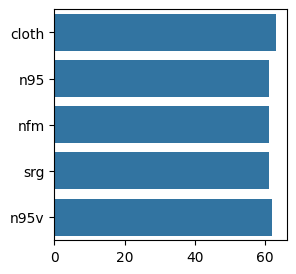

In [12]:
types_of_mask= train[0][1]
no_of_masks = []
for _ in range(1,6):
    no_of_masks.append(len(train[_][0]))
plt.figure(figsize = (3,3))
sns.barplot(y = types_of_mask, x = no_of_masks)

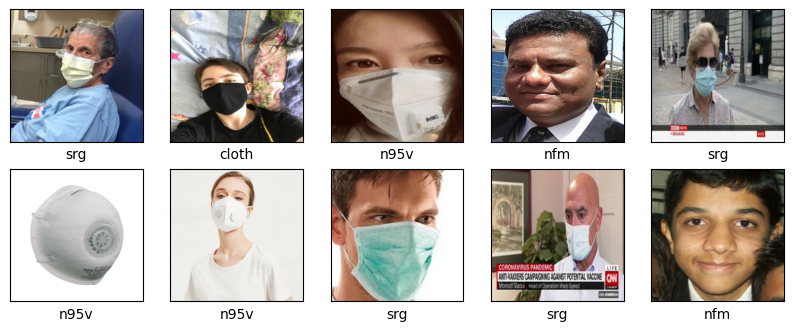

In [13]:
plt.figure(figsize = (10,10))
for _ in range(10):
    plt.subplot(5, 5, _+1)
    plt.yticks([])
    plt.xticks([])
    plt.grid(False)
    data = images[_]
    plt.xlabel(label_names[labels[_]])
    plt.imshow(data);

In [14]:
image_size = (224, 224)
batch_size = 32
train_datagen = ImageDataGenerator(rescale = 1./255,
                            shear_range = 0.4,        #Shear Intensity
                            zoom_range = 0.4,         #Range for random zoom
                            horizontal_flip = True,   #Randomly flip inputs horizontally.
                            validation_split = 0.15,  #Fraction of images reserved for validation
                            rotation_range=20,        #Degree range for random rotations.
                            width_shift_range=0.2,
                            height_shift_range=0.2)

In [15]:
train_ds = train_datagen.flow_from_directory(r"/content/drive/MyDrive/facemask/Custome data/train/Images",
                                      target_size = image_size,
                                      batch_size = batch_size,
                                      class_mode = 'categorical',
                                      subset = 'training',
                                      color_mode="rgb")

val_ds = train_datagen.flow_from_directory(r"/content/drive/MyDrive/facemask/Custome data/test/Images",
                                      target_size = image_size,
                                      batch_size = batch_size,
                                      class_mode = 'categorical',
                                      subset = 'validation',
                                      color_mode="rgb")

Found 1664 images belonging to 5 classes.
Found 47 images belonging to 5 classes.


In [16]:
train_ds.class_indices

{'cloth': 0, 'n95': 1, 'n95v': 2, 'nfm': 3, 'srg': 4}

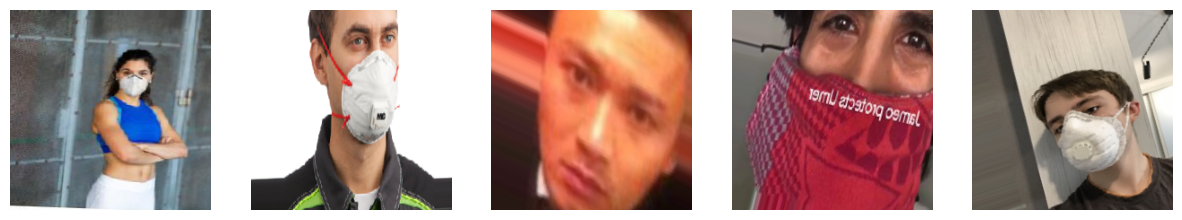

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(15,15))

for i in range(5):
    image = next(train_ds)[0][0]
    image = np.squeeze(image)
    ax[i].imshow(image)
    ax[i].axis(False)

In [24]:
m_model=tf.keras.applications.MobileNetV2()

In [28]:
inputs = Input(shape=(224, 224, 3))
basem_input=m_model.layers[1].input
basem_output=m_model.layers[-2].output
basem_input

<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_164>

In [29]:
finalm_output = layers.Dense(128)(basem_output)
finalm_ouput= layers.Activation('relu')(finalm_output)
finalm_output = layers.Dense(64)(finalm_ouput)
finalm_ouput = layers.Activation('relu')(finalm_output)
finalm_output = layers.Dense(5,activation='softmax')(finalm_ouput)

In [30]:
mob_model = keras.Model(inputs=basem_input,outputs=finalm_output)

In [31]:
mob_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,430,533 (9.27 MB)

 Trainable params: 2,396,421 (9.14 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [32]:
mob_model.compile(loss="categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])

In [33]:
checkpoint = ModelCheckpoint(filepath="basemodel.h5",
                                 monitor='val_accuracy',
                                 save_best_only=True,
                                 save_weights_only=False,
                                 verbose=1
                                 )

callback = [checkpoint]

In [34]:
mob_hist=mob_model.fit(train_ds, epochs=5, validation_data=val_ds,callbacks=[callback])

Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4395 - loss: 1.4038
Epoch 1: val_accuracy improved from None to 0.70213, saving model to basemodel.h5



Epoch 1: finished saving model to basemodel.h5
52/52 ━━━━━━━━━━━━━━━━━━━━ 240s 4s/step - accuracy: 0.5763 - loss: 1.1386 - val_accuracy: 0.7021 - val_loss: 0.8869
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7827 - loss: 0.6301
Epoch 2: val_accuracy did not improve from 0.70213
52/52 ━━━━━━━━━━━━━━━━━━━━ 198s 4s/step - accuracy: 0.7987 - loss: 0.5767 - val_accuracy: 0.6596 - val_loss: 0.8333
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8624 - loss: 0.3939
Epoch 3: val_accuracy improved from 0.70213 to 0.76596, saving model to basemodel.h5



Epoch 3: finished saving model to basemodel.h5
52/52 ━━━━━━━━━━━━━━━━━━━━ 196s 4s/step - accuracy: 0.8714 - loss: 0.3774 - val_accuracy: 0.7660 - val_loss: 0.7219
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8953 - loss: 0.2959
Epoch 4: val_accuracy did not improve from 0.76596
52/52 ━━━━━━━━━━━━━━━━━━━━ 208s 4s/step - accuracy: 0.9020 - loss: 0.2836 - val_accuracy: 0.7660 - val_loss: 0.6848
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9209 - loss: 0.2289
Epoch 5: val_accuracy improved from 0.76596 to 0.89362, saving model to basemodel.h5



Epoch 5: finished saving model to basemodel.h5
52/52 ━━━━━━━━━━━━━━━━━━━━ 199s 4s/step - accuracy: 0.9189 - loss: 0.2317 - val_accuracy: 0.8936 - val_loss: 0.3089


In [35]:
mob_model.save("/content/drive/MyDrive/facemask/basemodel")

ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=/content/drive/MyDrive/facemask/basemodel.

In [36]:
new_model = tf.keras.models.load_model('/content/drive/MyDrive/facemask/basemodel')
new_model.summary()

ValueError: File format not supported: filepath=/content/drive/MyDrive/facemask/basemodel. Keras 3 only supports V3 `.keras` files and legacy H5 format files (`.h5` extension). Note that the legacy SavedModel format is not supported by `load_model()` in Keras 3. In order to reload a TensorFlow SavedModel as an inference-only layer in Keras 3, use `keras.layers.TFSMLayer(/content/drive/MyDrive/facemask/basemodel, call_endpoint='serving_default')` (note that your `call_endpoint` might have a different name).

In [ ]:
def predictor(img, model):
    image = cv2.imread(img)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))
    image = np.array(image, dtype = 'float32')/255.0
    plt.imshow(image)
    image = image.reshape(1, 224,224,3)

    label_names = train_ds.class_indices
    dict_class = dict(zip(list(range(len(label_names))), label_names))
    clas = model.predict(image).argmax()
    name = dict_class[clas]
    return name
    #print('The given image is of \nClass: {0} \nSpecies: {1}'.format(clas, name))

In [ ]:
predictor(r"/content/drive/MyDrive/facemask/Custome data/test/Images/cloth/396.jpg", new_model)

In [ ]:
predictor(r"/content/drive/MyDrive/facemask/Custome data/test/Images/n95v/399.png", new_model)

In [ ]:
import numpy as np
import cv2
import random

# multiple cascades: https://github.com/Itseez/opencv/tree/master/data/haarcascades

face_cascade = cv2.CascadeClassifier('/content/drive/MyDrive/facemask/haarcascade files/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('/content/drive/MyDrive/facemask/haarcascade files/haarcascade_eye.xml')
mouth_cascade = cv2.CascadeClassifier('/content/drive/MyDrive/facemask/haarcascade files/haarcascade_mcs_mouth.xml')
upper_body = cv2.CascadeClassifier('/content/drive/MyDrive/facemask/haarcascade files/haarcascade_upperbody.xml')

# Adjust threshold value in range 80 to 105 based on your light.
bw_threshold = 80

# User message
font = cv2.FONT_HERSHEY_SIMPLEX
org = (30, 30)
wearing_mask_font_color = (255, 255, 255)
not_wearing_mask_font_color = (0, 0, 255)
thickness = 2
font_scale = 1
wearing_mask = "Thank You for wearing MASK"
not_wearing_mask = "Please wear MASK to defeat Corona"

# Read video
cap = cv2.VideoCapture(0)

while 1:
    # Get individual frame
    ret, img = cap.read()
    img = cv2.flip(img,1)

    # Convert Image into gray
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Convert image in black and white
    (thresh, black_and_white) = cv2.threshold(gray, bw_threshold, 255, cv2.THRESH_BINARY)
    cv2.imshow('black_and_white', black_and_white)

    # detect face
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)

    # Face prediction for black and white
    faces_bw = face_cascade.detectMultiScale(black_and_white, 1.1, 4)


    if(len(faces) == 0 and len(faces_bw) == 0):
        cv2.putText(img, "No face found...", org, font, font_scale, wearing_mask_font_color, thickness, cv2.LINE_AA)
    elif(len(faces) == 0 and len(faces_bw) == 1):
        # It has been observed that for white mask covering mouth, with gray image face prediction is not happening
        cv2.putText(img, wearing_mask, org, font, font_scale, wearing_mask_font_color, thickness, cv2.LINE_AA)
    else:
        # Draw rectangle on gace
        for (x, y, w, h) in faces:
            cv2.rectangle(img, (x, y), (x + w, y + h), (255, 255, 255), 2)
            roi_gray = gray[y:y + h, x:x + w]
            roi_color = img[y:y + h, x:x + w]


            # Detect lips counters
            mouth_rects = mouth_cascade.detectMultiScale(gray, 1.5, 5)

            # Face detected but Lips not detected which means person is wearing mask
            if(len(mouth_rects) == 0):
                masktype = predictor(img,mob_model)
                cv2.putText(img, masktype, org, font, font_scale, wearing_mask_font_color, thickness, cv2.LINE_AA)
            else:
                for (mx, my, mw, mh) in mouth_rects:

                    if(y < my < y + h):
                        # Face and Lips are detected but lips coordinates are within face cordinates which means lips prediction is true and
                        # person is not wearing mask
                        cv2.putText(img, not_wearing_mask, org, font, font_scale, not_wearing_mask_font_color, thickness, cv2.LINE_AA)

                        cv2.rectangle(img, (mx, my), (mx + mh, my + mw), (0, 0, 255), 3)
                        break    # Show frame with results
    plt.imshow('Mask Detection', img)
    k = cv2.waitKey(30) & 0xff
    if k == 27:
        break

# Release video
cap.release()
cv2.destroyAllWindows()

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

In [ ]:
from IPython.display import Image
try:
  filename = take_photo()
  print('Saved to {}'.format(filename))

  # Show the image which was just taken.
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))